In [1968]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import patsy
import geopandas as gpd

In [1969]:
base = "../outputs/tables/"
y = "y_pv"  # <-- change this "y_pv", "y_storage", "y_chargers", "y_wind_mw", "any_turbines"

def prep_outcomes_per_capita(df, pop_col="total_population", min_pop=1000):
    """Create per-capita + log1p outcomes; filter tiny-pop ZIPs."""
    df = df.copy()
    df[pop_col] = pd.to_numeric(df[pop_col], errors="coerce")
    df = df[df[pop_col].notna() & (df[pop_col] >= min_pop)].copy()

    pop = df[pop_col]
    df["level2_chargers_per_1k"] = df["level2_chargers"] * 1000 / pop
    df["y_level2_chargers"] = np.log1p(df["level2_chargers_per_1k"])

    df["level1_chargers_per_1k"] = df["level1_chargers"] * 1000 / pop
    df["y_level1_chargers"] = np.log1p(df["level1_chargers_per_1k"])

    df["dc_fast_chargers_per_1k"] = df["dc_fast_chargers"] * 1000 / pop
    df["y_dc_fast_chargers"] = np.log1p(df["dc_fast_chargers_per_1k"])

    df["chargers_per_1k"] = df["total_chargers"] * 1000 / pop
    df["y_chargers"] = np.log1p(df["chargers_per_1k"])

    df["pv_kw_per_1k"] = df["PV_system_size_DC"] * 1000 / pop
    df["y_pv"] = np.log1p(df["pv_kw_per_1k"])

    df["storage_mw_per_100k"] = df["storage_capacity_mw"] * 100000 / pop
    df["y_storage"] = np.log1p(df["storage_mw_per_100k"])

    df["wind_mw_per_100k"] = df["wind_capacity_mw"] * 100000 / pop
    df["y_wind_mw"] = np.log1p(df["wind_mw_per_100k"])

    df["y_turbines"] = np.log1p(df["wind_turbine_count"])
    df["any_turbines"] = (df["wind_turbine_count"] > 0).astype(int)

    return df

def center_cols(df, cols):
    """Mean-center columns for interaction models."""
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c + "_c"] = df[c] - df[c].mean()
    return df

def run_ols(formula, df, cluster_col=None):
    """Run OLS with HC1 SEs by default; optional clustered SEs."""
    m = smf.ols(formula=formula, data=df)

    if cluster_col is None:
        return m.fit(cov_type="HC1")
    res = m.fit()
    used_idx = res.model.data.row_labels
    groups = df.loc[used_idx, cluster_col].copy()
    groups = groups.fillna("MISSING").astype(str)
    return m.fit(cov_type="cluster", cov_kwds={"groups": groups})

def quick_print(res, title=""):
    if title:
        print("\n" + "="*80)
        print(title)
        print("="*80)
    print(res.summary().tables[0])
    print(res.summary().tables[1])
    res.summary2().tables[1].to_csv(base + title + ".csv")

def vif_from_formula(formula, df, exclude_prefixes=("C(",), drop_intercept=True):
    y, X = patsy.dmatrices(formula, df, return_type="dataframe")

    if drop_intercept and "Intercept" in X.columns:
        X = X.drop(columns=["Intercept"])

    # optionally exclude fixed-effect dummy columns
    if exclude_prefixes:
        keep = []
        for col in X.columns:
            if not any(col.startswith(pref) for pref in exclude_prefixes):
                keep.append(col)
        X = X[keep]

    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False)

    return vif

In [1970]:
#### THIS IS JUST FOR CALCULATING DIFFERENT FEATURES
#### ONLY MODIFY TO ADD FEATURES
df = pd.read_csv("../data/processed/combined_der_dataset_w_controls_predictors.csv")
df.drop(columns=['Unnamed: 0'], inplace=True)
df.rename(columns={"ghi_mean_kwh_m2_day_2024":"ghi_mean_kwh_m2_day_2023",
"wind_ws10m_mean_2024": "wind_ws10m_mean_2023",
    "wind_ws50m_mean_2024": "wind_ws50m_mean_2023"}, inplace=True)
# numeric coercion for key vars (safe)
for c in [
    "median_household_income","poverty_rate",
    "pct_black","pct_hispanic","pct_asian",
    "cdd65_2023","hdd65_2023","t2m_mean_c_2023",
    "ghi_mean_kwh_m2_day_2023","total_population",
    "lat","lon"
]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# fill utility_type if you plan to use it
if "utility_type" in df.columns:
    df["utility_type"] = df["utility_type"].fillna("POU")

print(df.shape, df.columns[:10])
df["log_median_household_income"] = np.log1p(df["median_household_income"])
df["log_median_housing_value"] = np.log1p(df["median_housing_value"])
df = prep_outcomes_per_capita(df, min_pop=1000)

# keep only rows with core predictors present
core_needed = ["median_household_income", "pct_black", "pct_hispanic", "pct_asian"]
df = df.dropna(subset=[c for c in core_needed if c in df.columns]).copy()

df["stand_cdd65_2023"] = (df["cdd65_2023"] - np.mean(df["cdd65_2023"]))/np.std(df["cdd65_2023"])
df["stand_hdd65_2023"] = (df["hdd65_2023"] - np.mean(df["hdd65_2023"]))/np.std(df["hdd65_2023"])
# make a separate standardized copy for coefficient-comparison plots
### COPY AFTER HERE
# df = df.copy()

# cols_to_standardize = [
#     "log_median_household_income",
#     "pct_black",
#     "pct_hispanic",
#     "pct_asian",
#     "poverty_rate",
#     "wind_ws50m_mean_2023"
# ]

# # only include columns that actually exist
# cols_to_standardize = [c for c in cols_to_standardize if c in df.columns]

# scaler = StandardScaler()
# df[cols_to_standardize] = scaler.fit_transform(df[cols_to_standardize])

# # if you want CDD/HDD standardized through sklearn too, use the raw versions instead of the manual stand_ vars:
# climate_cols_to_standardize = [c for c in ["cdd65_2023", "hdd65_2023"] if c in df.columns]
# if climate_cols_to_standardize:
#     df[climate_cols_to_standardize] = StandardScaler().fit_transform(df[climate_cols_to_standardize])

# outcomes available
outcomes = [c for c in ["y_chargers", "y_pv", "y_storage", "y_wind_mw", "y_turbines"] if c in df.columns]
outcomes, df.shape
print(df.columns)

(2572, 43) Index(['Unnamed: 0.1', 'zip_code', 'PV_system_size_DC', 'total_chargers',
       'level1_chargers', 'level2_chargers', 'dc_fast_chargers', 'zev_count',
       'plant_capacity_mw', 'storage_capacity_mw'],
      dtype='object')
Index(['Unnamed: 0.1', 'zip_code', 'PV_system_size_DC', 'total_chargers',
       'level1_chargers', 'level2_chargers', 'dc_fast_chargers', 'zev_count',
       'plant_capacity_mw', 'storage_capacity_mw', 'wind_capacity_mw',
       'wind_turbine_count', 'median_household_income', 'poverty_rate',
       'pct_bachelors_plus', 'pct_black', 'pct_hispanic', 'pct_asian',
       'median_housing_value', 'total_population', 'ghi_mean_kwh_m2_day_2023',
       't2m_mean_c_2023', 't2m_max_mean_c_2023', 't2m_min_mean_c_2023',
       't2m_summer_mean_c_2023', 'cdd65_2023', 'hdd65_2023',
       'wind_ws10m_mean_2023', 'wind_ws50m_mean_2023', 'lat', 'lon', 'acronym',
       'utility', 'utility_type', 'overlap_area_m2', 'overlap_share_of_zip',
       'kwh_annual_total', '

<Axes: >

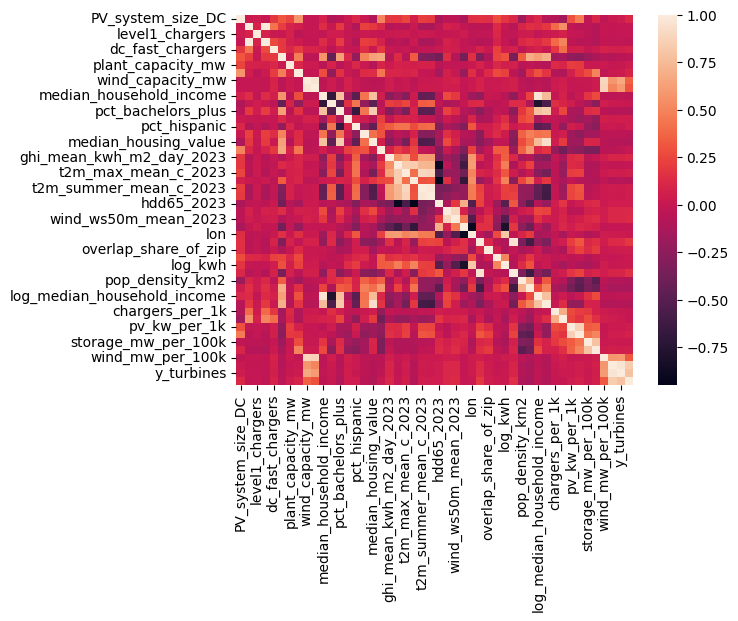

In [1971]:
corr = df[['PV_system_size_DC', 'total_chargers',
       'level1_chargers', 'level2_chargers', 'dc_fast_chargers', 'zev_count',
       'plant_capacity_mw', 'storage_capacity_mw', 'wind_capacity_mw',
       'wind_turbine_count', 'median_household_income', 'poverty_rate',
       'pct_bachelors_plus', 'pct_black', 'pct_hispanic', 'pct_asian',
       'median_housing_value', 'total_population', 'ghi_mean_kwh_m2_day_2023',
       't2m_mean_c_2023', 't2m_max_mean_c_2023', 't2m_min_mean_c_2023',
       't2m_summer_mean_c_2023', 'cdd65_2023', 'hdd65_2023',
       'wind_ws10m_mean_2023', 'wind_ws50m_mean_2023', 'lat', 'lon',
       'overlap_area_m2', 'overlap_share_of_zip',
       'kwh_annual_total', 'log_kwh',
       'area_km2', 'pop_density_km2', 'log_pop_density',
       'log_median_household_income', 'log_median_housing_value',
       'chargers_per_1k', 'y_chargers', 'pv_kw_per_1k', 'y_pv',
       'storage_mw_per_100k', 'y_storage', 'wind_mw_per_100k', 'y_wind_mw',
       'y_turbines', 'any_turbines']].corr()

sns.heatmap(corr)

In [1972]:
#### This is where the variables are defined to be used in the models
income = "log_median_household_income"
race = ["pct_black", "pct_hispanic", "pct_asian"]

# optional control: include poverty_rate or not
controls_common = ["poverty_rate", "total_population"]

# climate strategies
controls_3A = ["cdd65_2023", "hdd65_2023"]  # degree-days
controls_3B = ["t2m_mean_c_2023"]          # temp-only
controls_3C = ["ghi_mean_kwh_m2_day_2023"] # PV only
controls_3D = ["wind_ws50m_mean_2023"] # wind only
controls_cur = None
if y == "y_pv":
    controls_cur = controls_3C
elif y == "y_storage":
    controls_cur = controls_3A
elif y == "y_chargers":
    controls_cur = controls_3A
elif y == "y_wind_mw" or y == "any_turbines":
    controls_cur = controls_3D
print(controls_cur)
# SES proxies
ses_bach = ["pct_bachelors_plus"]
ses_house = ["log_median_housing_value"]

# FE and clustering columns
utility_fe = "C(utility)"
cluster_utility = "utility"

df["county_geoid"] = df["county_geoid"].astype(str)
county_fe = "C(county_geoid)"

latlon = ["lat","lon"]
lat = ["lat"]
lon = ["lon"]

# optional demand proxy (only if you merged it)
demand_proxy = "log_kwh"
controls_common, controls_3A, controls_3B, utility_fe

term_labels = {
    "cdd65_2023": "Cooling degree days",
    "stand_cdd65_2023": "Standardizde cooling degree days",
    "stand_hdd65_2023": "Standardizde heating degree days",
    "hdd65_2023": "Heating degree days",
    "ghi_mean_kwh_m2_day_2023": "Solar irradiance (GHI)",
    "wind_ws10m_mean_2023": "Wind speed (10m)",
    "wind_ws50m_mean_2023": "Wind speed (50m)",
    "poverty_rate": "Poverty rate",
    "pct_bachelors_plus": "% Bachelor's+",
    "pct_black": "% Black",
    "pct_hispanic": "% Hispanic",
    "pct_asian": "% Asian",
    "log_median_household_income": "Log median household income",
    "log_median_housing_value": "Log median housing value",
    "log_pop_density": "Log population density",
    "log_kwh": "Log annual electricity demand",
    "y_pv": "Solar PV adoption",
    "y_chargers": "EV charger availability",
    "y_storage": "Storage deployment",
    "y_wind_mw": "Wind capacity",
    "any_turbines": "Contains turbines"
}

['wind_ws50m_mean_2023']


In [1973]:
def build_formula(y, climate_controls, extra_terms=None, fe_terms=None,
                  keepincome=True, demand_proxy=None, controls_common = ["poverty_rate"]):
    rhs = []
    if keepincome:
        rhs.append(income)
    rhs += race
    rhs += list(controls_common)
    if demand_proxy is not None:
        rhs.append(demand_proxy)
    rhs += list(climate_controls)
    if extra_terms:
        rhs += list(extra_terms)
    if fe_terms:
        rhs += list(fe_terms)
    seen = set()
    rhs = [x for x in rhs if not (x in seen or seen.add(x))]

    return f"{y} ~ " + " + ".join(rhs)

Model 1 (Baseline, degree-days climate)

In [1974]:
f1 = build_formula(
    y,
    climate_controls=controls_cur,
    controls_common=["poverty_rate"],
    fe_terms=[])
res1 = run_ols(f1, df)
title = f"{y} | Model 1 baseline (climate controls)"
quick_print(res1, title)
print(vif_from_formula(f1, df).head(30))


any_turbines | Model 1 baseline (climate controls)
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     3.448
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00219
Time:                        08:28:31   Log-Likelihood:                 606.39
No. Observations:                1394   AIC:                            -1199.
Df Residuals:                    1387   BIC:                            -1162.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

**Model 1 (baseline)**
In our baseline specification, the dependent variable is log(1 + chargers per 10,000 residents), which retains ZIP codes with zero chargers and reduces skew. Using OLS with heteroskedasticity-robust (HC1) standard errors, we find that higher Black, Hispanic, and Asian population shares are each associated with lower charger availability, controlling for median household income, poverty rate, and climate demand (HDD/CDD). For example, a 10 percentage point increase in Hispanic share is associated with roughly a 7% decrease in (1 + chargers per 10,000). Median household income is not statistically significant in this baseline.

Model 2 (SES robustness: add ONE proxy)

In [1975]:
# bachelors proxy
f2a = build_formula(y,
                    climate_controls=controls_cur,
                    extra_terms=ses_bach,
                    keepincome = True,
                    controls_common=["poverty_rate"])
res2a = run_ols(f2a, df)
quick_print(res2a, f"{y} | Model 2 (add bachelors)")
print(vif_from_formula(f2a, df).head(30))

# housing proxy
f2b = build_formula(y,
                    climate_controls=controls_cur,
                    extra_terms=ses_house,
                    keepincome = True,
                    controls_common=["poverty_rate"])
res2b = run_ols(f2b, df)
quick_print(res2b, f"{y} | Model 2 (add housing value)")
print(vif_from_formula(f2b, df).head(30))



any_turbines | Model 2 (add bachelors)
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     3.975
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           0.000260
Time:                        08:28:31   Log-Likelihood:                 611.64
No. Observations:                1394   AIC:                            -1207.
Df Residuals:                    1386   BIC:                            -1165.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

**Model 2 (SES robustness: add one SES proxy)**
For Model 2, I’m basically asking: “If I add one more socioeconomic status dimension, do the race-share relationships fall apart — or do they stick?” When I add pct_bachelors_plus (2A), I still see negative coefficients for Black, Hispanic, and Asian share, and those are still statistically significant, which matters because it suggests the pattern isn’t only an income/SES story. In this version, pct_bachelors_plus is positive and significant, and something interesting happens with income: median household income becomes statistically significant but negative, which is a classic sign that the SES variables are stepping on each other a bit (your VIFs also reflect that). When I run the alternative version with median_housing_value (2B), I get the same overall vibe: race-share coefficients stay negative and significant, housing value is positive and significant, and income again shows up negative. So my takeaway is: Model 2 doesn’t “undo” Model 1 — it mostly reinforces that the race-share associations persist, while also showing that SES controls are highly correlated with each other and can reshuffle who “gets credit” in the model. That’s exactly why it’s a robustness check and not something I’d treat as the new baseline.

Model 3 climate robustness (3B temp-only; 3C PV-only)

In [1976]:
# 3A CDD and HDD only
f3a = build_formula(y, climate_controls=controls_3A)
res3a = run_ols(f3a, df)
quick_print(res3a, f"{y} | Model 3A (HDD + CDD)")
print(vif_from_formula(f3a, df).head(30))

# 3B temp only
f3b = build_formula(y, climate_controls=controls_3B)
res3b = run_ols(f3b, df)
quick_print(res3b, f"{y} | Model 3B (temp only)")
print(vif_from_formula(f3b, df).head(30))

# 3C temp only
f3c = build_formula(y, climate_controls=controls_3C)
res3c = run_ols(f3c, df)
quick_print(res3c, f"{y} | Model 3C (GHI only)")
print(vif_from_formula(f3c, df).head(30))


any_turbines | Model 3A (HDD + CDD)
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.850
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00591
Time:                        08:28:31   Log-Likelihood:                 598.90
No. Observations:                1394   AIC:                            -1182.
Df Residuals:                    1386   BIC:                            -1140.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

**Model 3A (HDD + CDD)**

For Model 3A, I keep the outcome as log(1 + chargers per 10,000 residents) and control for climate demand using HDD and CDD, with HC1 robust standard errors. The main pattern stays the same: higher Black, Hispanic, and Asian population shares are each associated with lower charger availability, even after controlling for income and climate demand. HDD is strongly positive, while CDD is negative but not statistically significant in this spec, which suggests heating-related demand is doing more work than cooling for explaining charger differences here.

**Model 3B (temperature-only)**

In Model 3B, I switch the climate controls to mean temperature only (t2m_mean) instead of degree days. The results are very consistent with the baseline story: Black, Hispanic, and Asian population shares remain negative and highly significant. Temperature itself is also significant, which makes sense as a broad proxy for climate and geography. This version is mainly a robustness check showing the race-share relationships don’t depend on using HDD/CDD specifically.

**Model 3C (GHI only)**

In Model 3C, I use solar resource (GHI) as the control instead of the degree-day or temperature climate measures. Even with this alternative “location/resource” control, the same core result holds: higher Black, Hispanic, and Asian shares are still associated with lower charger availability, and GHI is statistically significant as well. Because GHI is more naturally tied to solar potential than EV charger siting, I treat this as an extra robustness specification rather than the main climate-control approach for chargers.

Income is negatively associated with charger density even in the bivariate model. This is not a sign-flip artifact from controls. However, this remains an observational association and likely reflects correlated geographic/urban-form and EV-adoption factors; we treat income primarily as a control and test robustness using additional controls and alternative denominators (e.g., chargers per ZEV).

Model 4 interactions (centered)

In [1977]:
df_int = center_cols(df, [income] + race)

f4 = (
    f"{y} ~ log_median_household_income_c + pct_black_c + pct_hispanic_c + pct_asian_c"
    + (" + " + " + ".join(["poverty_rate"] + controls_cur) if (controls_common or controls_cur) else "")
    + " + log_median_household_income_c:pct_black_c"
    + " + log_median_household_income_c:pct_hispanic_c"
    + " + log_median_household_income_c:pct_asian_c"
)
# can change 3A to 3D
res4 = run_ols(f4, df_int)
quick_print(res4, f"{y} | Model 4 interactions (centered)")
print(vif_from_formula(f4, df_int).head(30))

f4R = (
    f"{y} ~ log_median_household_income_c + pct_black_c + pct_hispanic_c + pct_asian_c"
    + (" + " + " + ".join(controls_common + controls_cur) if (controls_common or controls_cur) else "")
    + " + log_median_household_income_c:pct_black_c"
    + " + log_median_household_income_c:pct_hispanic_c"
    + " + log_median_household_income_c:pct_asian_c"
)

res4R = run_ols(f4R, df_int)
quick_print(res4R, f"{y} | Model 4R interactions (centered)")
print(vif_from_formula(f4R, df_int).head(30))


any_turbines | Model 4 interactions (centered)
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     3.267
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           0.000607
Time:                        08:28:32   Log-Likelihood:                 609.88
No. Observations:                1394   AIC:                            -1200.
Df Residuals:                    1384   BIC:                            -1147.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

Although the positive coefficient on poverty rate in the charger models may initially appear counterintuitive, it is not indicative of model misspecification. The association is already positive and statistically significant in a sparse specification with only climate controls and remains stable after adding demographic controls, interaction terms, and population. In addition, variance inflation factors remain moderate, suggesting that the result is not driven by extreme multicollinearity. Given that the charger outcome reflects public charging availability rather than private household technology adoption, a positive poverty association is substantively plausible and may reflect shared-charging need or equity-oriented infrastructure siting.

The positive poverty-rate coefficient in the aggregate charger models does not appear to reflect model misspecification. When charger types are separated, the association is concentrated in Level 2 chargers and is absent for Level 1 and DC fast chargers. This subtype-specific pattern is consistent with the distinct siting logic of Level 2 infrastructure, which is more closely tied to destination charging and shared-access charging needs than either Level 1 or corridor-oriented fast charging.

**Model 4 (interactions, centered; no population)**

In Model 4, I add race × income interactions (with all interaction terms centered for cleaner interpretation) while keeping the same outcome, log(1 + chargers per 10,000 residents), and using HC1 robust standard errors. The main race-share coefficients stay strongly negative: higher Black, Hispanic, and Asian population shares are each associated with lower charger availability, even at average income. In this version, the interaction terms show some heterogeneity: income × Hispanic share is negative and statistically significant, while income × Asian share is positive and marginally significant. In other words, the income–charger relationship looks meaningfully different depending on ZIP racial composition in this specification.

**Model 4R (interactions, centered; adds total population)**

As a robustness check, Model 4R adds total population to the interaction model. Population is extremely predictive here (and the model fit jumps a lot), which suggests it’s capturing big structural differences across ZIPs. With population included, the main race-share coefficients remain negative and significant, but the interaction story becomes simpler: the income × Hispanic interaction is no longer significant, while the income × Asian interaction remains positive and significant. So the key takeaway is that the interaction results are somewhat sensitive to whether we control for ZIP size/urban structure, but the overall negative association between charger availability and race-share variables is consistently present across both versions.

Model 5 utility fixed effects (+ optional clustered SEs)

In [1978]:
if utility_fe:
    f5 = build_formula(y, climate_controls=controls_cur, fe_terms=[utility_fe])

    res5 = run_ols(f5, df)
    quick_print(res5, f"{y} | Model 5 utility FE")
    print(vif_from_formula(f5, df_int).head(30))

    res5C = run_ols(f5, df, cluster_col="county_geoid")
    quick_print(res5C, f"{y} | Model 5C clustered SEs by county")


any_turbines | Model 5 utility FE
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     2.805
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00439
Time:                        08:28:32   Log-Likelihood:                 522.50
No. Observations:                1293   AIC:                            -1027.
Df Residuals:                    1284   BIC:                            -980.5
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

**Model 5 (utility fixed effects, HC1)**

In Model 5, I add utility territory fixed effects (PG&E is the reference group, with dummy terms for SDG&E and SCE). This means I’m basically comparing ZIP codes within the same utility territory, holding constant utility-level stuff like big policy / infrastructure differences across utilities. Even with that “within-utility” comparison, the race-share coefficients stay negative and statistically significant: higher % Black, % Hispanic, and % Asian are each associated with lower log(1 + chargers per 10k). Roughly speaking, a 10 percentage point increase in (say) Hispanic share corresponds to about a 6–7% lower (1 + chargers per 10k) (since 0.1 \times -0.651 \approx -0.065). Income is also negative and significant in this spec (I’d describe that as a conditional relationship—once you hold constant race shares + climate + utility, the “leftover” variation income captures can flip signs). HDD is positive and significant; CDD is negative but only marginal here. Importantly, the utility dummy coefficients themselves aren’t significant, which suggests that once you control for the rest, SDG&E vs SCE vs PG&E differences aren’t what’s driving the within-sample variation in this outcome.

**Model 5C (same model, but clustered SEs by county)**

Model 5C is the same exact regression (so the coefficients do not change), but the standard errors are clustered by county, which is a tougher way to do inference if ZIP codes inside the same county are correlated. The main takeaway is that the story largely holds up: income and all three race-share variables are still significant, and HDD stays significant, while CDD becomes clearly not significant under clustering. So if you’re worried about “maybe I’m overstating significance because nearby ZIPs move together,” clustering by county is a solid check—and here, it mostly just makes the inference more conservative without wiping out the main patterns.

Because utility-territory identifiers are only available for PG&E, SCE, and SDG&E, Models 5 and 5C are estimated on the restricted sample of ZIP codes within these three utilities (N=1,020). As a result, the fixed-effect results should be interpreted as within-utility patterns for this subset of California ZIP codes, rather than statewide estimates.

Model 6 geography: county FE OR lat/lon

In [1979]:
# 6A Lat/Lon FE
f6a = build_formula(y, climate_controls=[], extra_terms=latlon)
res6a = run_ols(f6a, df)
quick_print(res6a, f"{y} | Model 6A lat and lon")
print(vif_from_formula(f6a, df).head(30))

# 6B County FE
f6b = build_formula(y, climate_controls=[], extra_terms=[county_fe])
res6b = run_ols(f6b, df)
quick_print(res6b, f"{y} | Model 6B county fe")
print(vif_from_formula(f6b, df).head(30))

res6_fe_cluster = run_ols(f1, df, cluster_col="county_geoid")
quick_print(res6_fe_cluster, f"{y} | No County FE + clustered SEs (county)")


any_turbines | Model 6A lat and lon
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.315
Date:                Sat, 04 Apr 2026   Prob (F-statistic):             0.0239
Time:                        08:28:32   Log-Likelihood:                 595.35
No. Observations:                1394   AIC:                            -1175.
Df Residuals:                    1386   BIC:                            -1133.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

**Model 5 — Utility fixed effects (PGE/SCE/SDGE only)**

In Model 5, I add utility fixed effects, so the comparisons are basically happening within the same utility territory (for the ZIPs where I actually have utility labels: mostly PGE/SCE/SDGE). Even after doing that, the race-share coefficients stay strongly negative: higher Black, Hispanic, and Asian shares are each associated with lower charger availability (in log(1 + chargers per 10k)). As a rough scale check, a 10 percentage point increase in Hispanic share corresponds to about a 6.3% decrease in (1 + chargers per 10k), and a 10pp increase in Black share corresponds to about an 11% decrease. The utility dummy terms themselves aren’t significant here (so the big story isn’t “SCE vs PGE”), but rather the within-utility pattern in the demographic variables. Income is negative and significant in this restricted sample, which I’d interpret cautiously since this model is only using the subset of ZIPs covered by those three utilities.

**Model 5C — Same model, but clustered standard errors by county**

Model 5C keeps the exact same RHS, but uses county-clustered standard errors, meaning I’m being more conservative about inference because ZIPs in the same county aren’t really independent. The main pattern basically holds: the race-share coefficients stay negative and statistically significant, and income stays negative/significant. The biggest practical change is that CDD becomes less convincing (not significant once clustered), while HDD stays significant. So the “headline” from this version is: even after controlling for utility territory and being conservative about SEs, the demographic associations don’t disappear.

**Model 1R — Baseline model with county-clustered SEs (no county FE)**

For Model 1R (baseline + county-clustered SEs, but no county fixed effects), the results are clean and still very interpretable. Black, Hispanic, and Asian shares are all negative and significant, poverty rate is positive and significant, and income is not significant once clustered. In terms of magnitude, a 10 percentage point increase in Hispanic share is associated with about a 7% decrease in (1 + chargers per 10k), and a 10pp increase in Black share is about a 12% decrease. HDD is strongly positive and significant; CDD is not. So I’d feel good logging this as “done” and moving on, because it’s a solid baseline with conservative inference that you can compare all the variants against.

Model 7 infrastructure controls

In [1980]:
# outcome -> columns to EXCLUDE from infrastructure controls
exclude_for_y = {
    "y_chargers": ["total_chargers", "level1_chargers", "level2_chargers", "dc_fast_chargers", "chargers_per_1k"],
    y: ["PV_system_size_DC", "pv_kw_per_1k"],
    "y_storage": ["storage_capacity_mw", "storage_mw_per_100k"],
    "y_wind_mw": ["wind_capacity_mw", "wind_mw_per_100k"],
    "y_turbines": ["wind_turbine_count"],
}

# candidate infrastructure controls (RAW)
infra_candidates = ["plant_capacity_mw", "storage_capacity_mw", "wind_capacity_mw", "wind_turbine_count", "PV_system_size_DC"]

infra = [c for c in infra_candidates if c in df.columns]
infra = [c for c in infra if c not in exclude_for_y.get(y, [])]

f7 = build_formula(y, climate_controls=controls_cur, extra_terms=infra)
res7 = run_ols(f7, df)
quick_print(res7, f"{y} | Model 7 (infrastructure controls, outcome-safe)")
print(vif_from_formula(f7, df).head(30))


any_turbines | Model 7 (infrastructure controls, outcome-safe)
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     3.642
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           8.32e-05
Time:                        08:28:32   Log-Likelihood:                 665.60
No. Observations:                1322   AIC:                            -1309.
Df Residuals:                    1311   BIC:                            -1252.
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

In [1981]:
# Create per-capita infrastructure controls once
pop = df["total_population"].replace(0, np.nan)

if "plant_capacity_mw" in df.columns:
    df["plant_mw_per_100k"] = df["plant_capacity_mw"] * 100000 / pop
if "storage_capacity_mw" in df.columns:
    df["storage_mw_per_100k"] = df["storage_capacity_mw"] * 100000 / pop
if "wind_capacity_mw" in df.columns:
    df["wind_mw_per_100k_ctrl"] = df["wind_capacity_mw"] * 100000 / pop
if "wind_turbine_count" in df.columns:
    df["turbines_per_100k"] = df["wind_turbine_count"] * 100000 / pop

infra_pc = [c for c in ["plant_mw_per_100k", "storage_mw_per_100k", "wind_mw_per_100k_ctrl"] if c in df.columns]
f7pc = build_formula(y, climate_controls=controls_cur, extra_terms=infra_pc)
res7pc = run_ols(f7pc, df)
quick_print(res7pc, f"{y} | Model 7 (per-capita infrastructure controls)")
print(vif_from_formula(f7pc, df).head(30))


any_turbines | Model 7 (per-capita infrastructure controls)
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     3.539
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           0.000238
Time:                        08:28:32   Log-Likelihood:                 629.96
No. Observations:                1322   AIC:                            -1240.
Df Residuals:                    1312   BIC:                            -1188.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

In Model 7, I add per-capita DER-intensity controls (distributed generation and storage capacity per 100k residents) to capture differences in local clean-energy buildout that could be correlated with EV charging availability. These DER measures are strongly associated with the outcome, and the model fit increases substantially. Even with these controls, higher Black, Hispanic, and Asian population shares remain negatively associated with charger availability. Median income becomes negative and significant in this specification, which I interpret as a conditional effect once DER buildout and other correlated factors are held fixed, rather than a standalone income–charger relationship.

Model 8 demand proxy robustness

In [1982]:
if demand_proxy:
    f8 = build_formula(y, climate_controls=controls_cur, extra_terms=[demand_proxy])
    res8 = run_ols(f8, df)
    quick_print(res8, f"{y} | Model 8 add demand proxy")
    print(vif_from_formula(f8, df).head(30))


any_turbines | Model 8 add demand proxy
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     3.105
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00299
Time:                        08:28:32   Log-Likelihood:                 461.80
No. Observations:                1225   AIC:                            -907.6
Df Residuals:                    1217   BIC:                            -866.7
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In Model 8, I add a demand proxy (log_kwh), measured as utility-reported electricity demand by ZIP code for PG&E, SCE, and SDG&E service territories. Using OLS with HC1 robust standard errors, I find log_kwh is negative and statistically significant, indicating that higher electricity demand is associated with slightly lower charger availability per 10,000 residents after controlling for income, demographic composition, and HDD/CDD. The negative coefficients on Black, Hispanic, and Asian population shares remain large and statistically significant, suggesting the main distributional pattern is not explained away by differences in local electricity demand.

In [1983]:
def make_formula(y, predictors):
    return f"{y} ~ " + " + ".join(predictors)

core_controls = ["poverty_rate"]
f_base = make_formula(y, controls_cur + core_controls)
f_pv = make_formula(y, controls_cur + core_controls + ["y_pv"])
f_chargers = make_formula(y, controls_cur + core_controls + ["y_chargers"])
f_both = make_formula(y, controls_cur + core_controls + ["y_pv", "y_chargers"])

for title, formula in {
    f"{y} | Model 1 baseline (no climate controls)": f_base,
    f"{y} | Model 9 + pv control": f_pv,
    f"{y} | Model 9 + charger control": f_chargers,
    f"{y} | Model 9 + charger + pv control": f_both,
}.items():
    res = run_ols(formula, df)
    quick_print(res, title)
    print(vif_from_formula(formula, df).head(15))


any_turbines | Model 1 baseline (no climate controls)
                            OLS Regression Results                            
Dep. Variable:           any_turbines   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     6.512
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00153
Time:                        08:28:33   Log-Likelihood:                 599.12
No. Observations:                1394   AIC:                            -1192.
Df Residuals:                    1391   BIC:                            -1177.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [1984]:
zip_gdf = gpd.read_file("../data/raw/boundaries/tl_2023_us_zcta520/tl_2023_us_zcta520.shp")
county_gdf = gpd.read_file("../data/raw/boundaries/tl_2023_us_county/tl_2023_us_county.shp")
ca_counties = county_gdf[county_gdf["STATEFP"] == "06"].copy()
ca_counties = ca_counties.to_crs(zip_gdf.crs)
ca_outline = ca_counties.dissolve()

ca_counties = county_gdf[county_gdf["STATEFP"] == "06"].copy()
print(zip_gdf.columns)
zip_gdf["zip_code"] = zip_gdf["ZCTA5CE20"].astype(str).str.zfill(5)
# or
# zip_gdf["zip_code"] = zip_gdf["GEOID20"].astype(str).str.zfill(5)
df["zip_code"] = df["zip_code"].astype(str).str.zfill(5)
ca_zips = set(df["zip_code"].dropna().unique())
zip_gdf = zip_gdf[zip_gdf["zip_code"].isin(ca_zips)].copy()
def make_paper_spatial_figure(
    df,
    zip_gdf,
    res,
    outcome_col,
    id_col="zip_code",
    observed_title=None,
    residual_title=None,
    residual_col="std_residual",
    observed_cmap="viridis",
    residual_cmap="coolwarm",
    figsize=(16, 7),
    hotspot_threshold=None,
    save_path=None,
    ca_outline_gdf=None
):
    """
    Create a paper-style two-panel spatial figure:
    left = observed outcome by ZIP
    right = model residuals by ZIP

    Parameters
    ----------
    df : pd.DataFrame
        Original modeling dataframe.
    zip_gdf : gpd.GeoDataFrame
        ZIP geometry dataframe.
    res : statsmodels results object
        Fitted regression results object.
    outcome_col : str
        Outcome column in df to map, e.g. 'y_pv' or 'y_storage'.
    id_col : str, default 'zip_code'
        Merge key present in both df and zip_gdf.
    observed_title : str or None
        Title for the observed map.
    residual_title : str or None
        Title for the residual map.
    residual_col : str, default 'std_residual'
        Residual column to plot; one of {'residual', 'std_residual'}.
    observed_cmap : str
        Colormap for observed values.
    residual_cmap : str
        Colormap for residuals.
    figsize : tuple
        Figure size.
    hotspot_threshold : float or None
        If provided, outline ZIPs with abs(residual) >= threshold on the residual panel.
        Best used with standardized residuals.
    save_path : str or None
        If provided, save figure to this path.

    Returns
    -------
    merged : gpd.GeoDataFrame
        GeoDataFrame used for plotting.
    fig, axes
        Matplotlib figure and axes.
    """
    # Copy and standardize merge keys
    df2 = df.copy()
    gdf2 = zip_gdf.copy()

    df2[id_col] = df2[id_col].astype(str).str.zfill(5)
    gdf2[id_col] = gdf2[id_col].astype(str).str.zfill(5)

    # Get rows used in model
    used_idx = res.model.data.row_labels
    diag = df2.loc[used_idx, [id_col]].copy()
    diag["fitted"] = res.fittedvalues
    diag["residual"] = res.resid
    diag["std_residual"] = (res.resid - np.mean(res.resid)) / np.std(res.resid)

    # Keep one observed value per ZIP
    observed = df2[[id_col, outcome_col]].drop_duplicates(subset=[id_col]).copy()

    # Merge onto geometry
    merged = gdf2.merge(observed, on=id_col, how="left")
    merged = merged.merge(diag, on=id_col, how="left")

    # California outer outline only
    ca_outline = merged.dissolve()

    # Default titles
    if observed_title is None:
        observed_title = f"{outcome_col} by ZIP"
    if residual_title is None:
        residual_title = f"{outcome_col} model standardized residuals" if residual_col == "std_residual" else f"{outcome_col} model residuals"

    # Residual color scale centered at zero
    vmax = np.nanmax(np.abs(merged[residual_col]))
    if np.isnan(vmax) or vmax == 0:
        vmax = 1.0

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Left: observed outcome
    merged.plot(
        column=outcome_col,
        cmap=observed_cmap,
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        ax=axes[0],
        missing_kwds={"color": "lightgray", "label": "No data"}
    )
    ca_outline.plot(
        ax=axes[0],
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )
    if ca_outline_gdf is not None:
        ca_outline_gdf.boundary.plot(
            ax=axes[0],
            color="black",
            linewidth=1.2,
            zorder=10
        )
    axes[0].set_title(observed_title)
    axes[0].axis("off")

    # Right: residuals
    merged.plot(
        column=residual_col,
        cmap=residual_cmap,
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        vmin=-vmax,
        vmax=vmax,
        ax=axes[1],
        missing_kwds={"color": "lightgray", "label": "No data"}
    )
    ca_outline.plot(
        ax=axes[1],
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )

    # Optional hotspot outlines
    if hotspot_threshold is not None:
        hotspots = merged[merged[residual_col].abs() >= hotspot_threshold]
        if len(hotspots) > 0:
            hotspots.boundary.plot(ax=axes[1], linewidth=0.8, color="black")
    if ca_outline_gdf is not None:
        ca_outline_gdf.boundary.plot(
            ax=axes[1],
            color="black",
            linewidth=1.2,
            zorder=10
        )
    axes[1].set_title(residual_title)
    axes[1].axis("off")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return merged, fig, axes

Index(['ZCTA5CE20', 'GEOID20', 'GEOIDFQ20', 'CLASSFP20', 'MTFCC20',
       'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20',
       'geometry'],
      dtype='object')


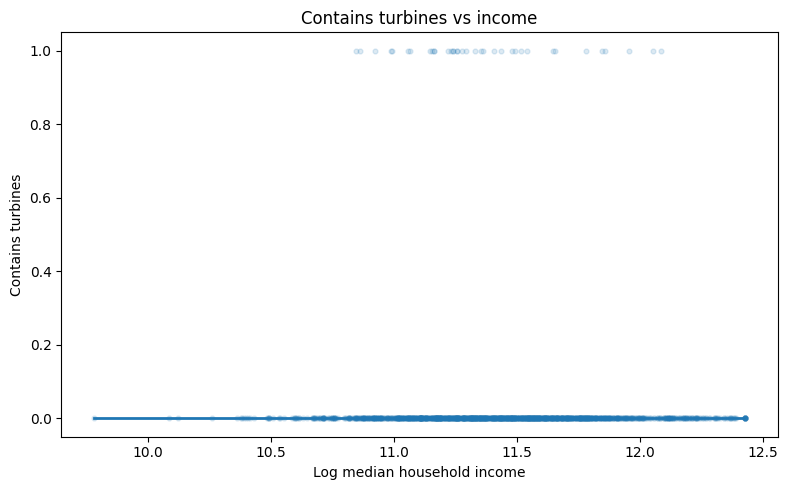

,x_grid,lowess,ci_low,ci_high
0,9.779284,0.0,0.0,0.0
1,9.792600,0.0,0.0,0.0
2,9.805917,0.0,0.0,0.0
3,9.819233,0.0,0.0,0.0
4,9.832549,0.0,0.0,0.0
...,...,...,...,...
195,12.375959,0.0,0.0,0.0
196,12.389275,0.0,0.0,0.0
197,12.402592,0.0,0.0,0.0
198,12.415908,0.0,0.0,0.0


In [1985]:
import statsmodels.api as sm

def lowess_with_bootstrap_ci(
    df,
    x_col,
    y_col,
    frac=0.35,
    n_boot=300,
    ci=95,
    grid_size=200,
    seed=42,
    xlabel=None,
    ylabel=None,
    title=None,
    save_path=None
):
    """
    Scatterplot with LOWESS curve and bootstrap confidence interval.
    """
    rng = np.random.default_rng(seed)

    d = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    x = d[x_col].to_numpy()
    y = d[y_col].to_numpy()

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    x_grid = np.linspace(x.min(), x.max(), grid_size)

    # Main LOWESS fit
    fit = sm.nonparametric.lowess(y, x, frac=frac, return_sorted=True)
    y_hat = np.interp(x_grid, fit[:, 0], fit[:, 1])

    # Bootstrap LOWESS fits
    boot_preds = np.zeros((n_boot, grid_size))
    n = len(d)

    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        xb = x[idx]
        yb = y[idx]

        ord_b = np.argsort(xb)
        xb = xb[ord_b]
        yb = yb[ord_b]

        fit_b = sm.nonparametric.lowess(yb, xb, frac=frac, return_sorted=True)
        boot_preds[b, :] = np.interp(x_grid, fit_b[:, 0], fit_b[:, 1])

    alpha = (100 - ci) / 2
    lower = np.percentile(boot_preds, alpha, axis=0)
    upper = np.percentile(boot_preds, 100 - alpha, axis=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x, y, alpha=0.15, s=12)
    ax.plot(x_grid, y_hat, linewidth=2)
    ax.fill_between(x_grid, lower, upper, alpha=0.2)

    ax.set_xlabel(xlabel or x_col)
    ax.set_ylabel(ylabel or y_col)
    ax.set_title(title or f"{y_col} vs {x_col} with LOWESS")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame({
        "x_grid": x_grid,
        "lowess": y_hat,
        "ci_low": lower,
        "ci_high": upper
    })

lowess_with_bootstrap_ci(
    df=df,
    x_col="log_median_household_income",
    y_col=y,
    frac=0.35,
    xlabel="Log median household income", # change
    ylabel=term_labels[y], # change
    title=f"{term_labels[y]} vs income", # change
    save_path=f"../outputs/figures/{term_labels[y]}_income_lowess.png"
)
# add different pairs of adoption versus predictors

In [1986]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def compare_linear_vs_nonlinear_models(
    df,
    y_col,
    x_cols,
    n_splits=5,
    random_state=42
):
    """
    Compare cross-validated predictive performance of linear and nonlinear models.
    Drops rows with missing y, keeps X imputation inside each pipeline.
    """
    d = df[x_cols + [y_col]].replace([np.inf, -np.inf], np.nan).copy()

    # crucial fix: drop rows with missing outcome
    d = d[d[y_col].notna()].copy()

    X = d[x_cols]
    y = d[y_col]

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    models = {
    "Linear": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Polynomial deg 2": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            random_state=random_state,
            n_jobs=-1
        ))
    ]),
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=random_state,
            n_jobs=-1
        ))
    ])
}

    rows = []
    for name, model in models.items():
        r2 = cross_val_score(model, X, y, cv=cv, scoring="r2")
        rmse = -cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="neg_root_mean_squared_error"
        )

        rows.append({
            "model": name,
            "n_obs": len(d),
            "cv_r2_mean": r2.mean(),
            "cv_r2_sd": r2.std(),
            "cv_rmse_mean": rmse.mean(),
            "cv_rmse_sd": rmse.std()
        })

    return pd.DataFrame(rows).sort_values("cv_r2_mean", ascending=False)

predictors = [
    "log_median_household_income",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "poverty_rate",
] + controls_cur

compare_linear_vs_nonlinear_models(
    df=df,
    y_col=y,
    x_cols=predictors
)

,model,n_obs,cv_r2_mean,cv_r2_sd,cv_rmse_mean,cv_rmse_sd
0,Linear,1394,0.003654,0.027961,0.155233,0.026653
1,Polynomial deg 2,1394,0.001232,0.071411,0.154996,0.025247
3,XGBoost,1394,-0.054731,0.157535,0.158213,0.022754
2,Random Forest,1394,-0.059320,0.126937,0.159100,0.024708


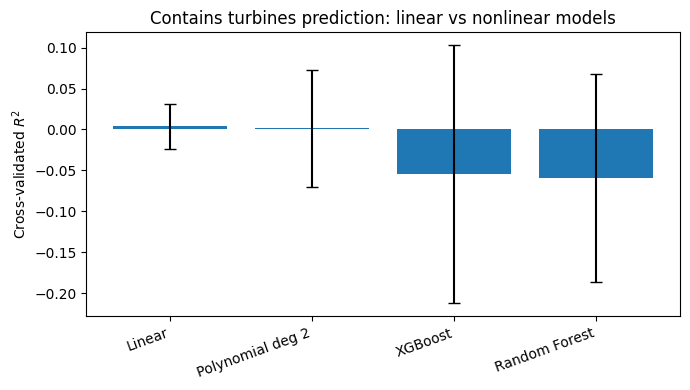

In [1987]:
def plot_model_comparison(results_df, title=None, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(results_df["model"], results_df["cv_r2_mean"], yerr=results_df["cv_r2_sd"], capsize=4)
    ax.set_ylabel("Cross-validated $R^2$")
    ax.set_title(title or "Predictive performance comparison")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

res_compare = compare_linear_vs_nonlinear_models(
    df=df,
    y_col=y,
    x_cols=predictors
)

plot_model_comparison(
    res_compare,
    title=f"{term_labels[y]} prediction: linear vs nonlinear models",
    save_path=f"../outputs/figures/{term_labels[y]}_model_comparison.png"
)

In [1988]:
def safe_slug(s):
    return re.sub(r"[^A-Za-z0-9]+", "_", s).strip("_").lower()

def export_spatial_maps_for_models(
    df,
    zip_gdf,
    outcome_col,
    outcome_title,
    model_results,
    id_col="zip_code",
    output_dir="../outputs/figures/",
    hotspot_threshold=2.0,
    ca_outline_gdf=None,
):
    """
    Generate and save a paper-style spatial figure for each fitted model result.

    Parameters
    ----------
    df : pd.DataFrame
        Original modeling dataframe.
    zip_gdf : gpd.GeoDataFrame
        ZIP geometry dataframe.
    outcome_col : str
        Outcome column in df, e.g. 'y_storage'.
    outcome_title : str
        Human-readable title prefix, e.g. 'Storage adoption by ZIP'.
    model_results : dict[str, statsmodels result]
        Mapping from model label to fitted result object.
    id_col : str
        Merge key.
    output_dir : str
        Folder to save figures into.
    hotspot_threshold : float or None
        Threshold for outlining large residual ZIPs.

    Returns
    -------
    dict
        Mapping from model label to saved path.
    """
    os.makedirs(output_dir, exist_ok=True)
    saved = {}

    for model_name, res in model_results.items():
        fname = f"{outcome_col}_{safe_slug(model_name)}_spatial_figure.png"
        save_path = os.path.join(output_dir, fname)

        gdf_out, fig, axes = make_paper_spatial_figure(
            df=df,
            zip_gdf=zip_gdf,
            res=res,
            outcome_col=outcome_col,
            id_col=id_col,
            observed_title=outcome_title,
            residual_title=f"{outcome_title} — {model_name} standardized residuals",
            hotspot_threshold=hotspot_threshold,
            save_path=save_path,
            ca_outline_gdf=ca_outline_gdf,
        )

        saved[model_name] = save_path
        plt.close(fig)

    return saved

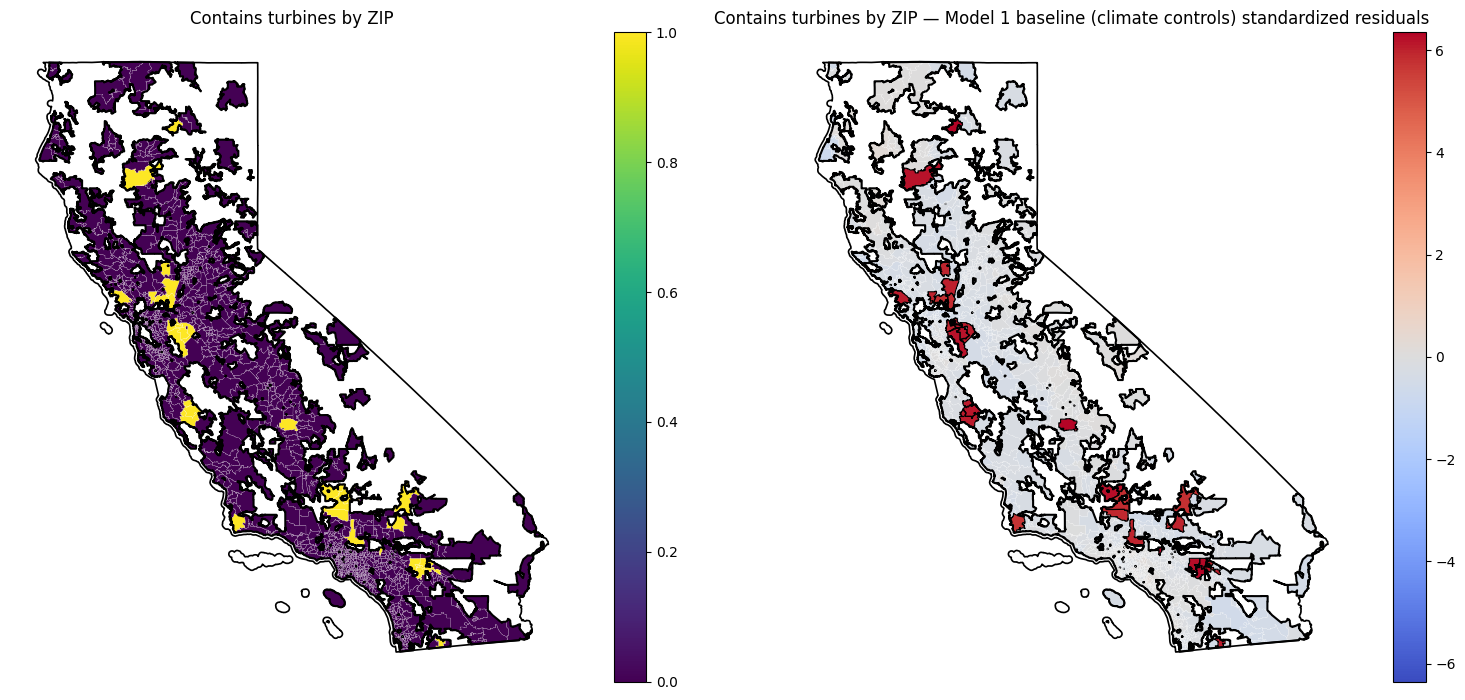

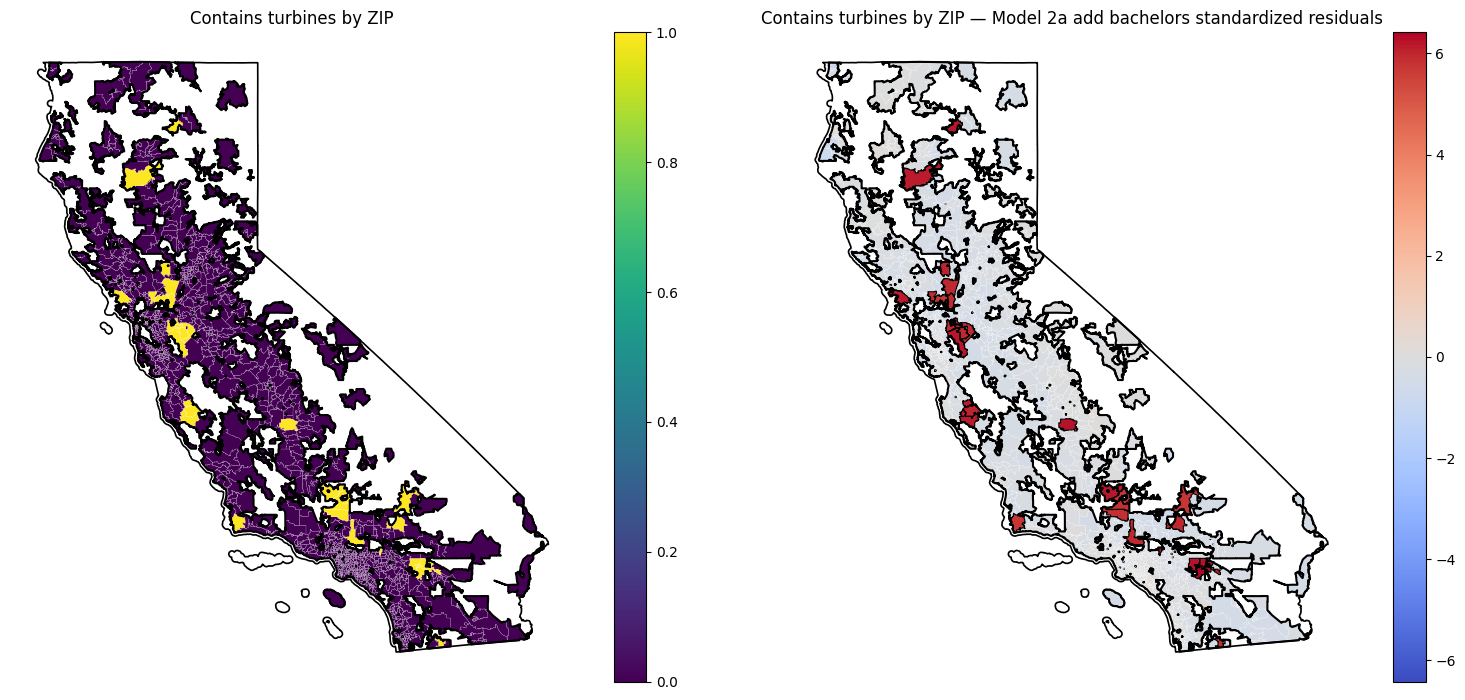

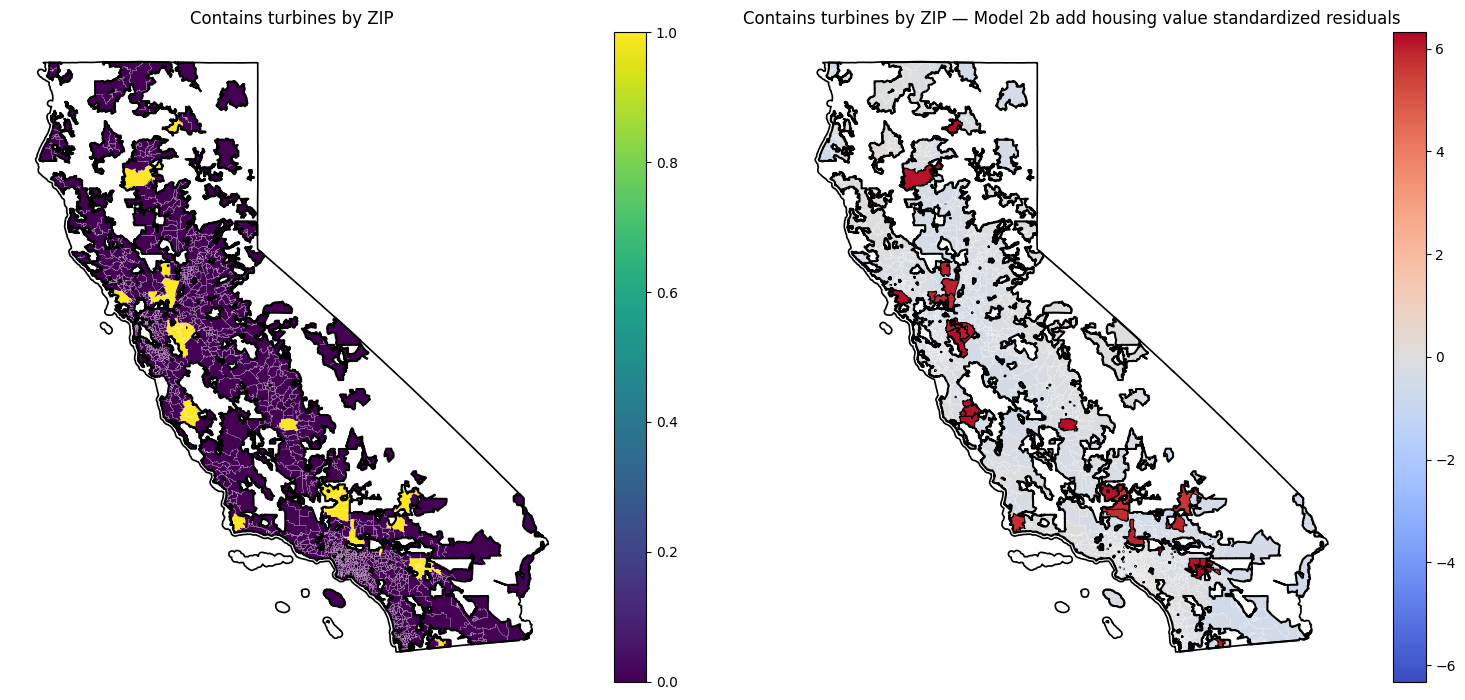

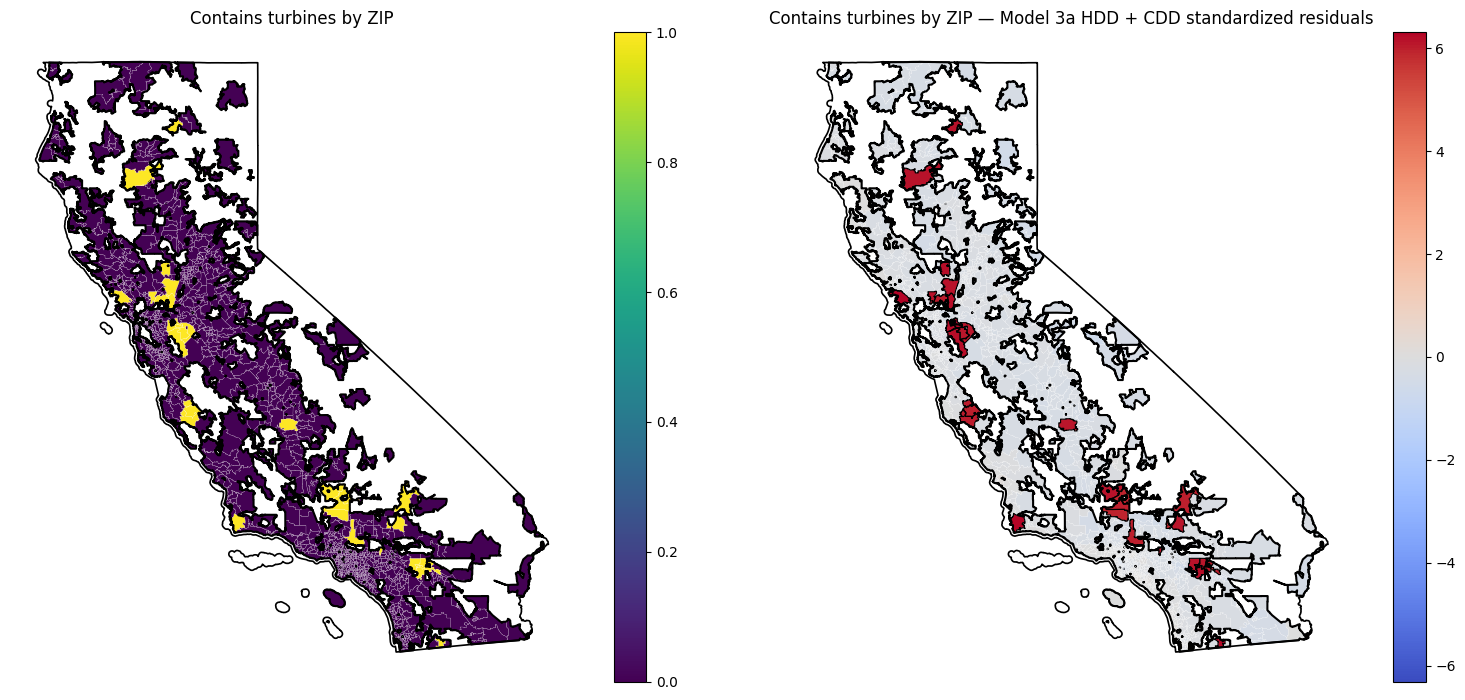

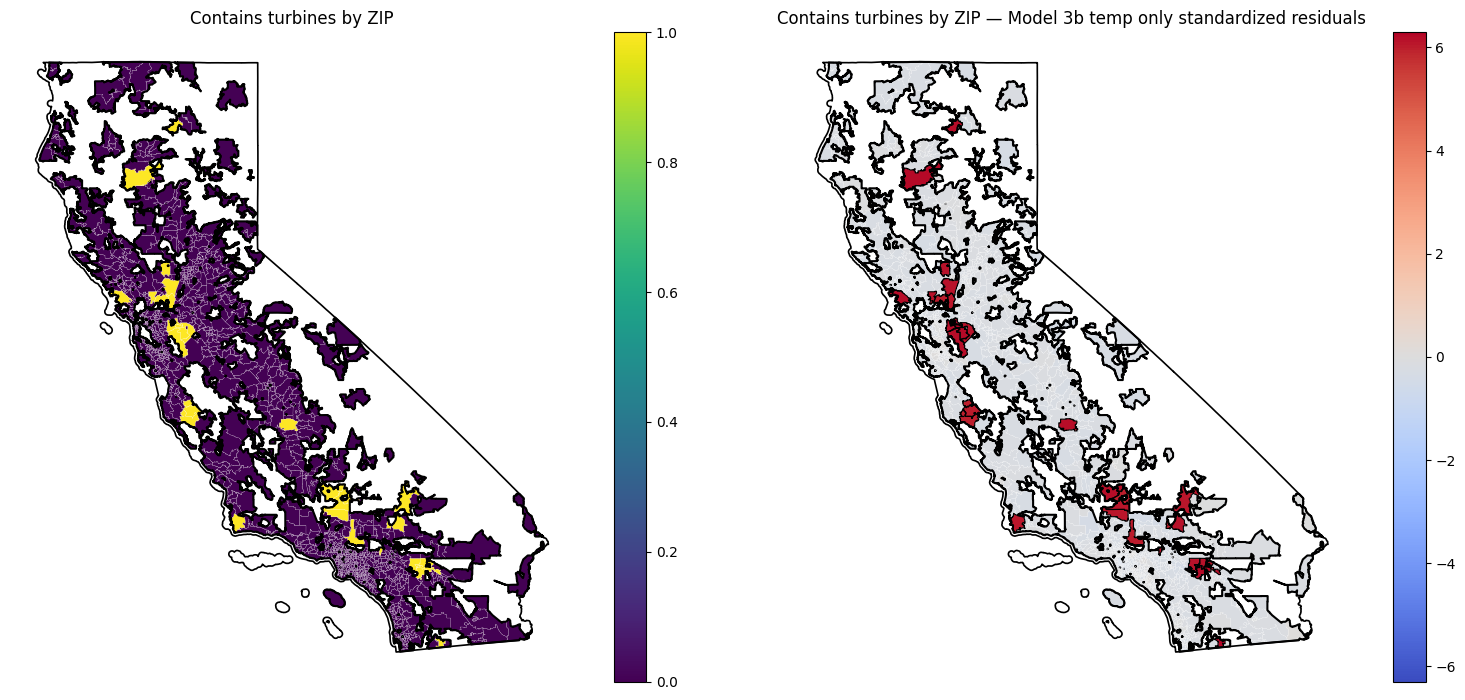

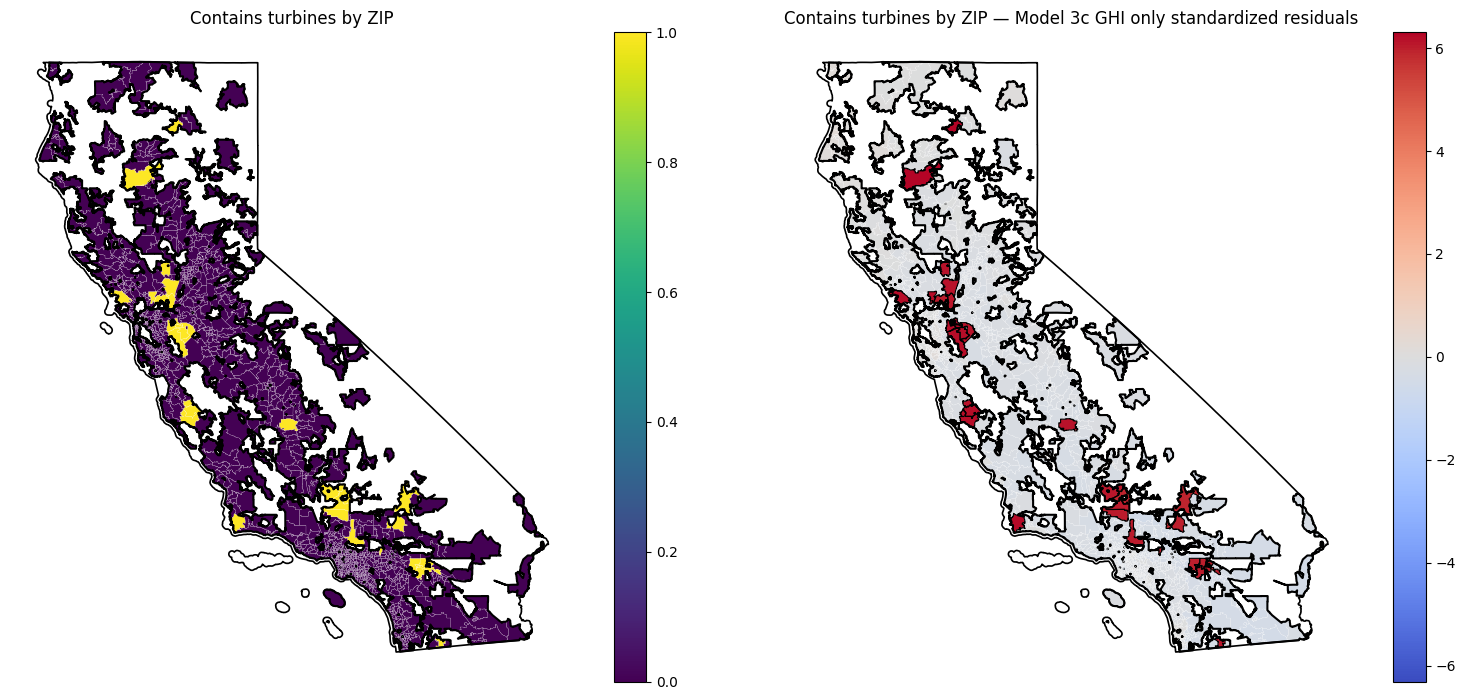

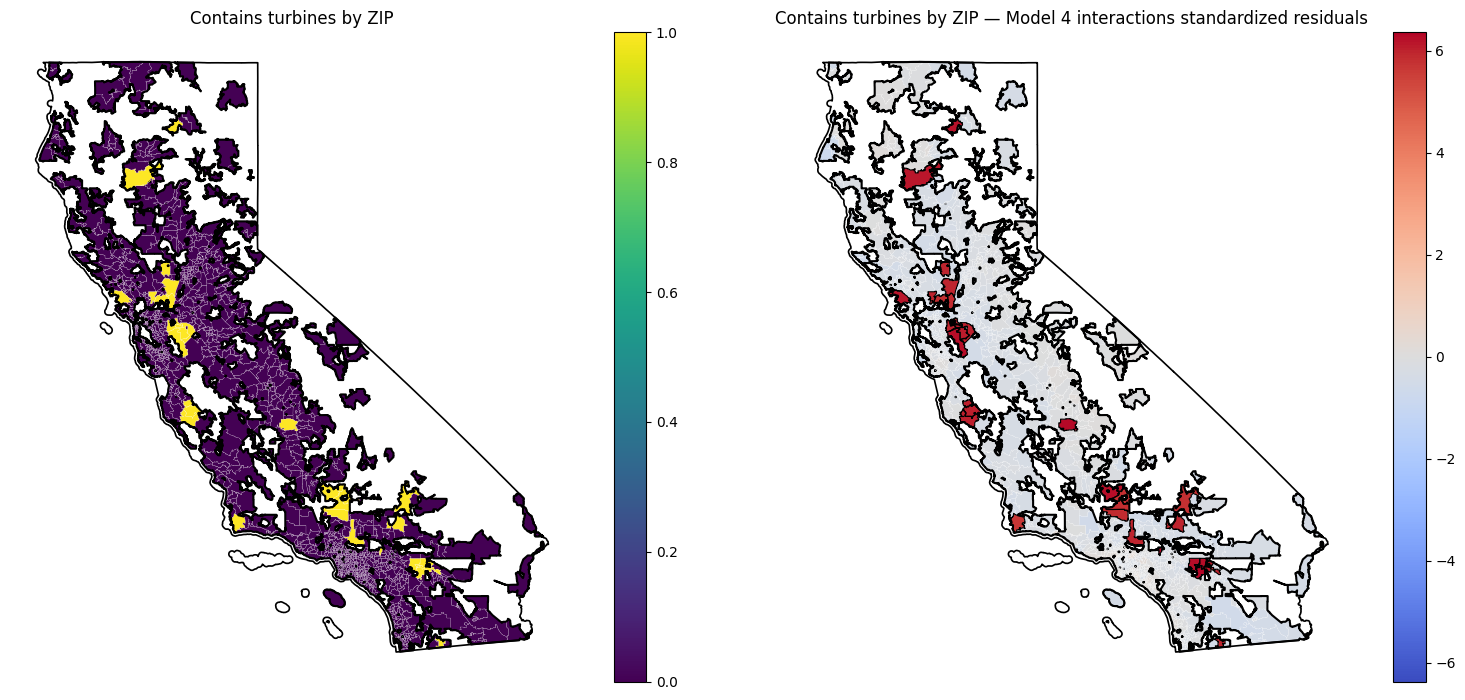

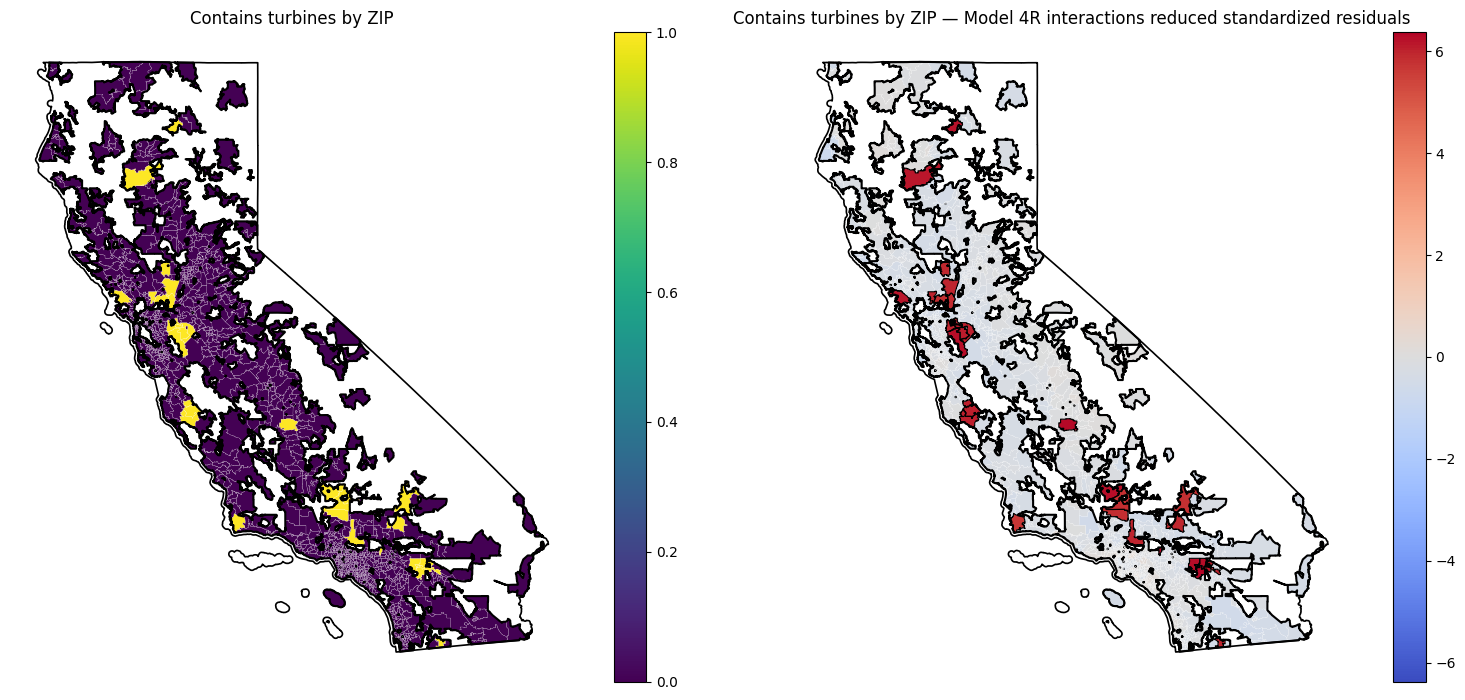

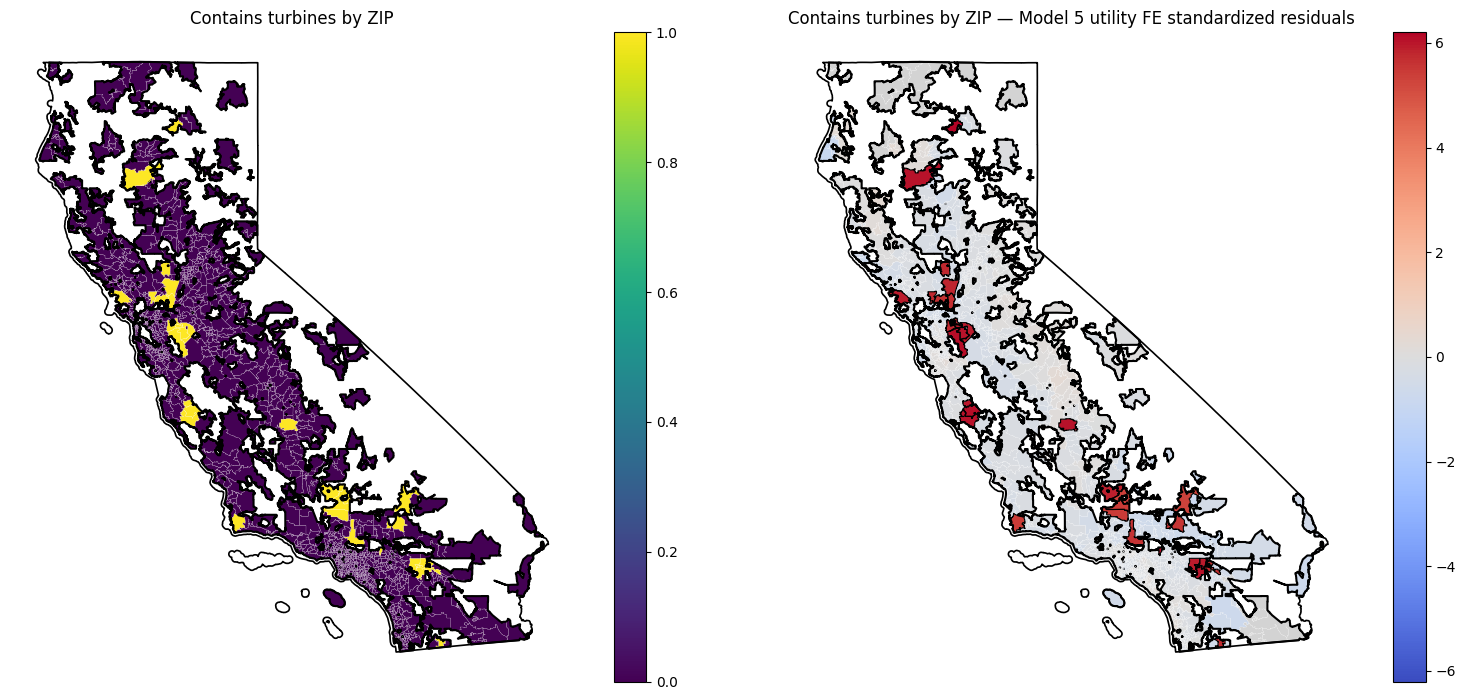

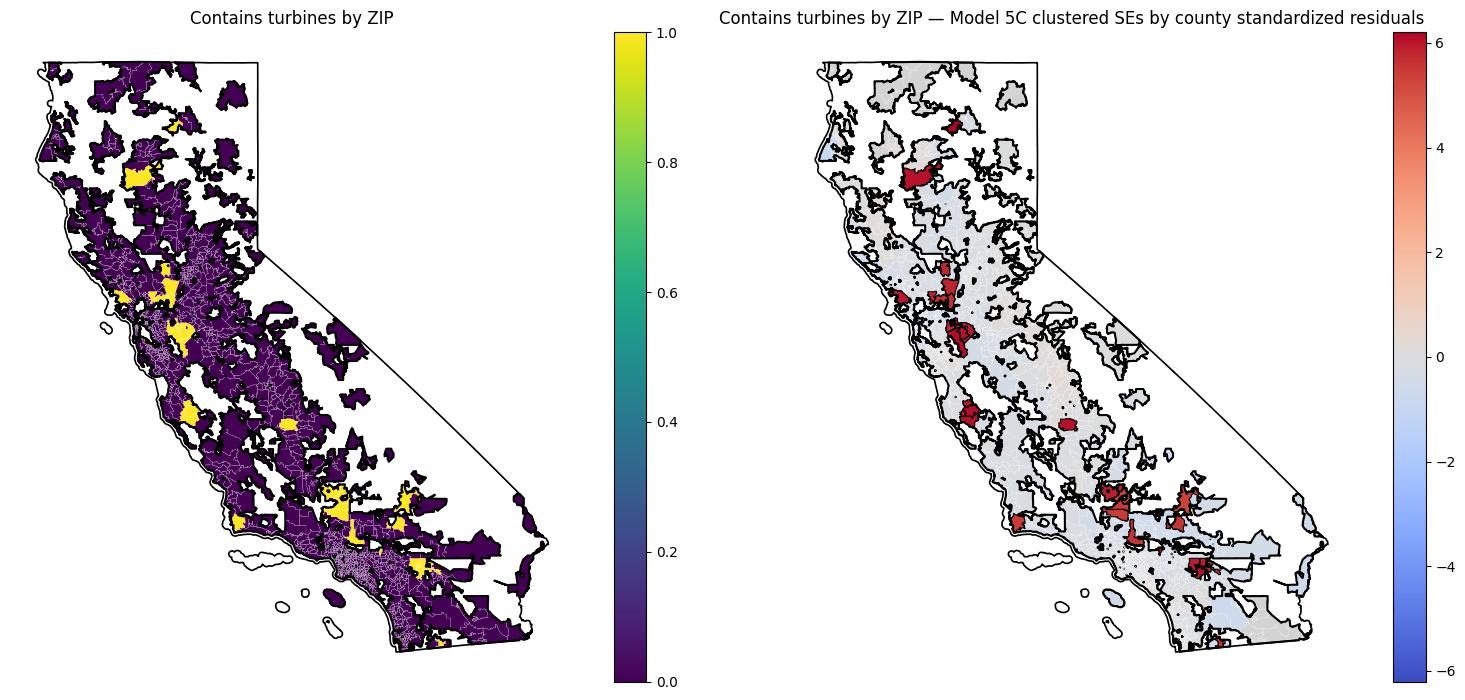

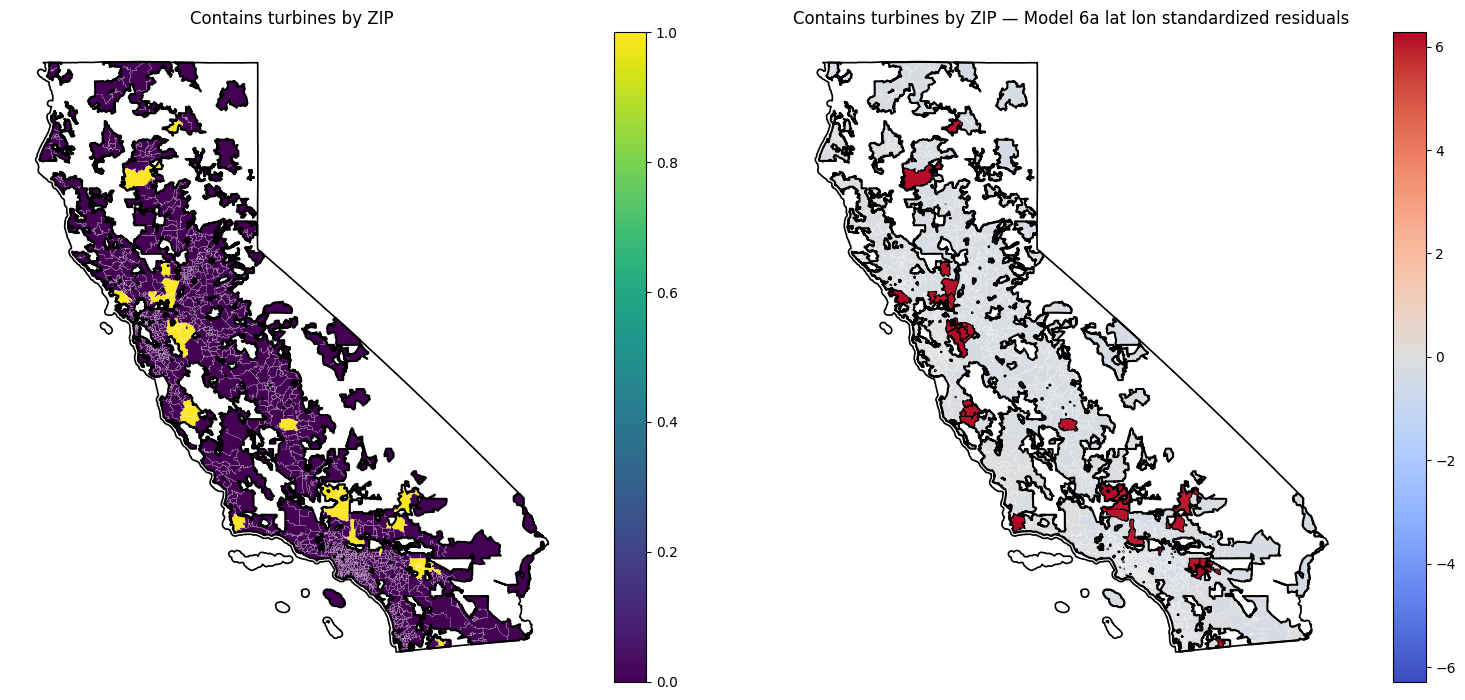

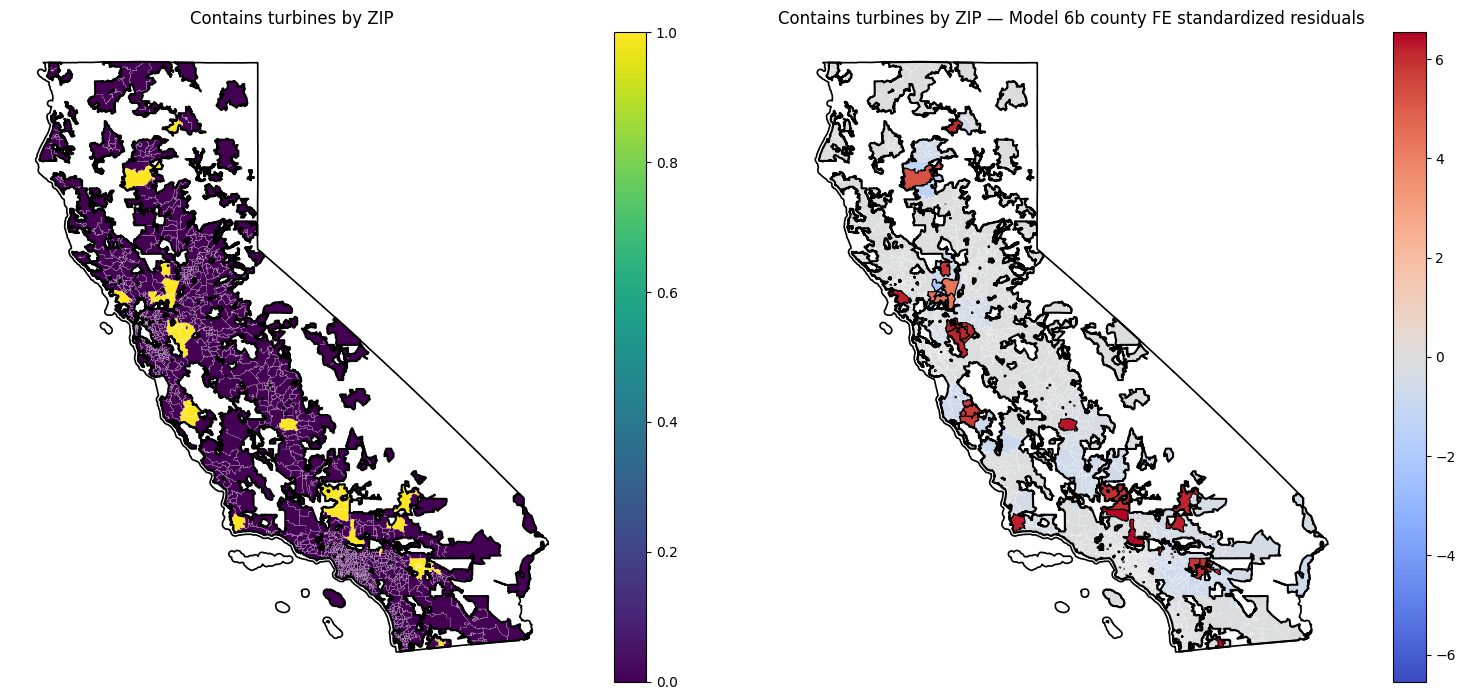

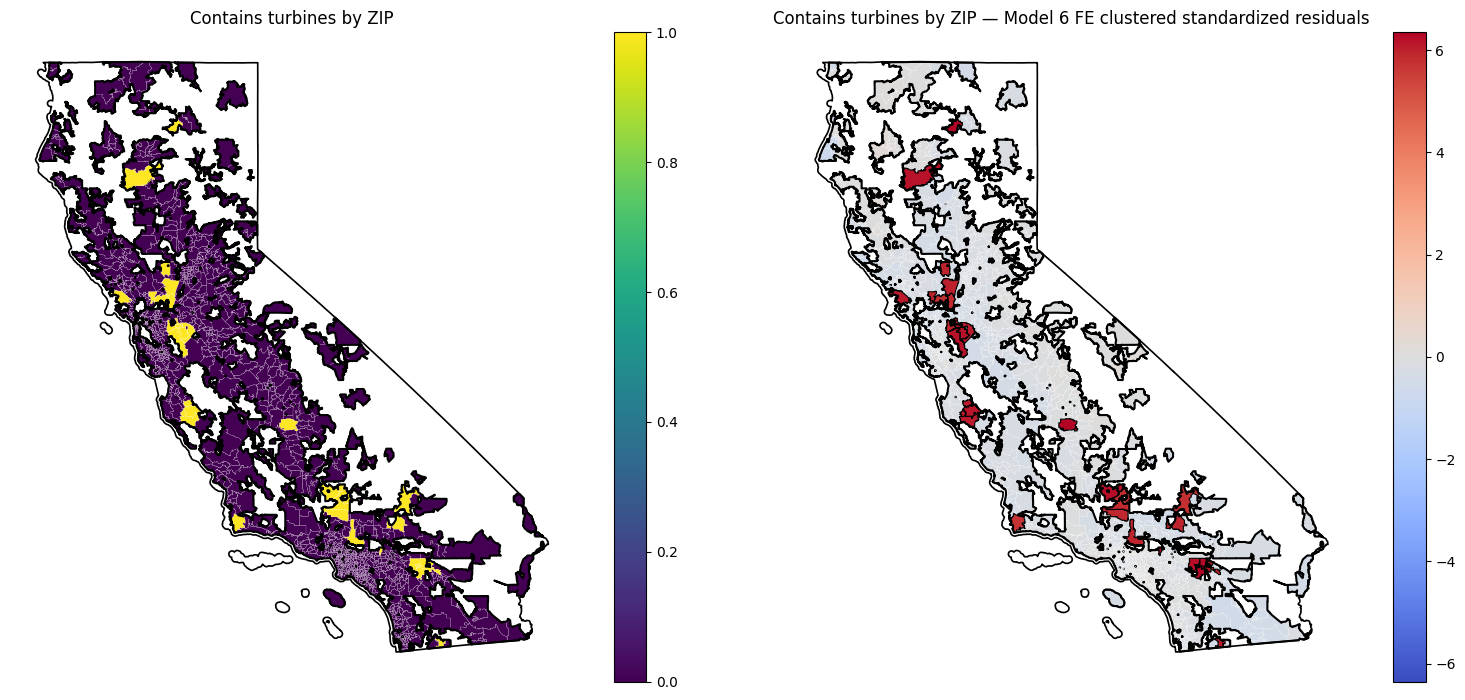

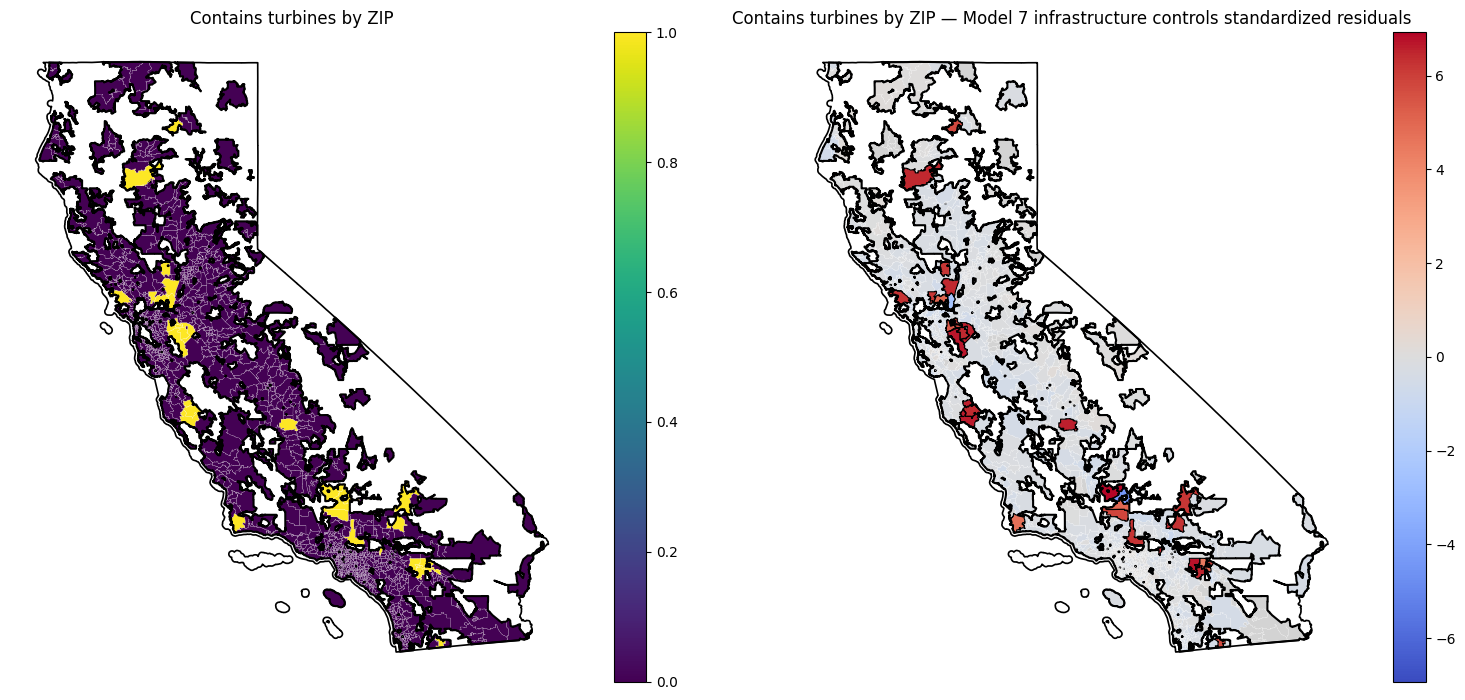

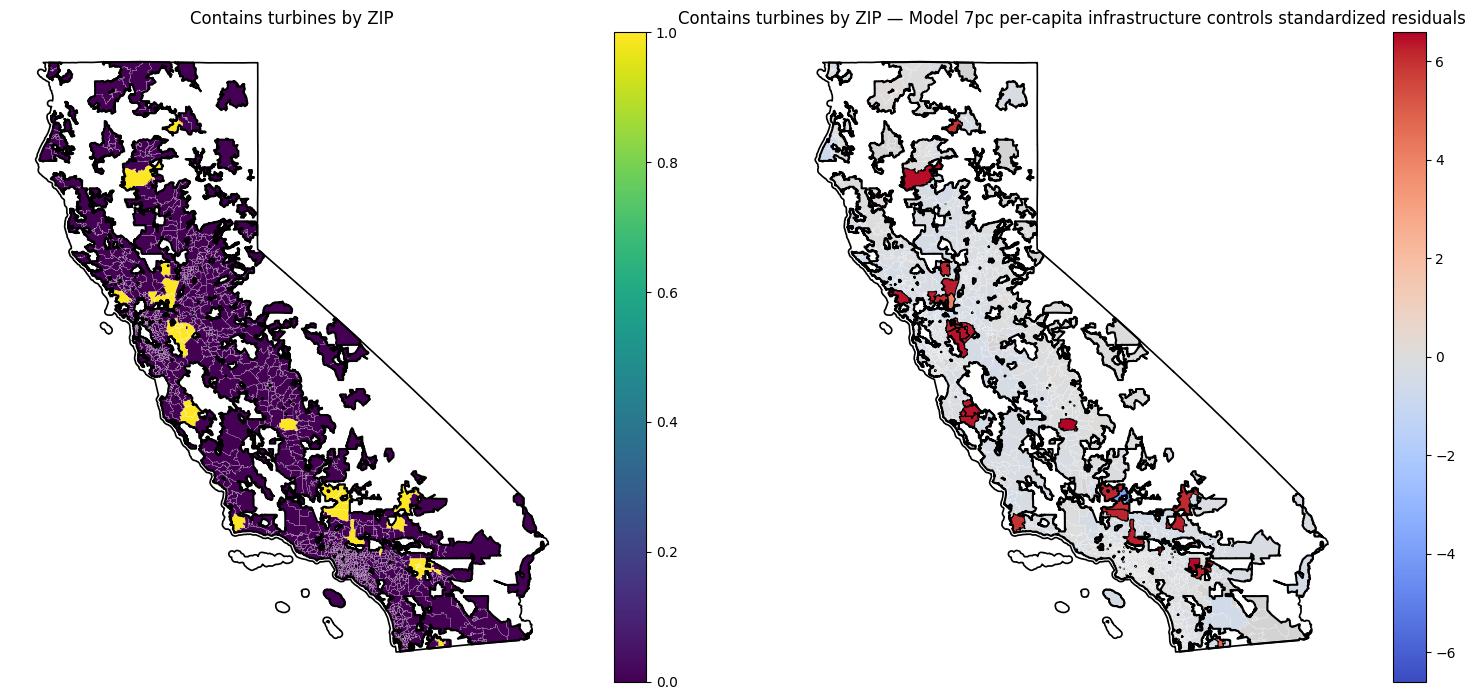

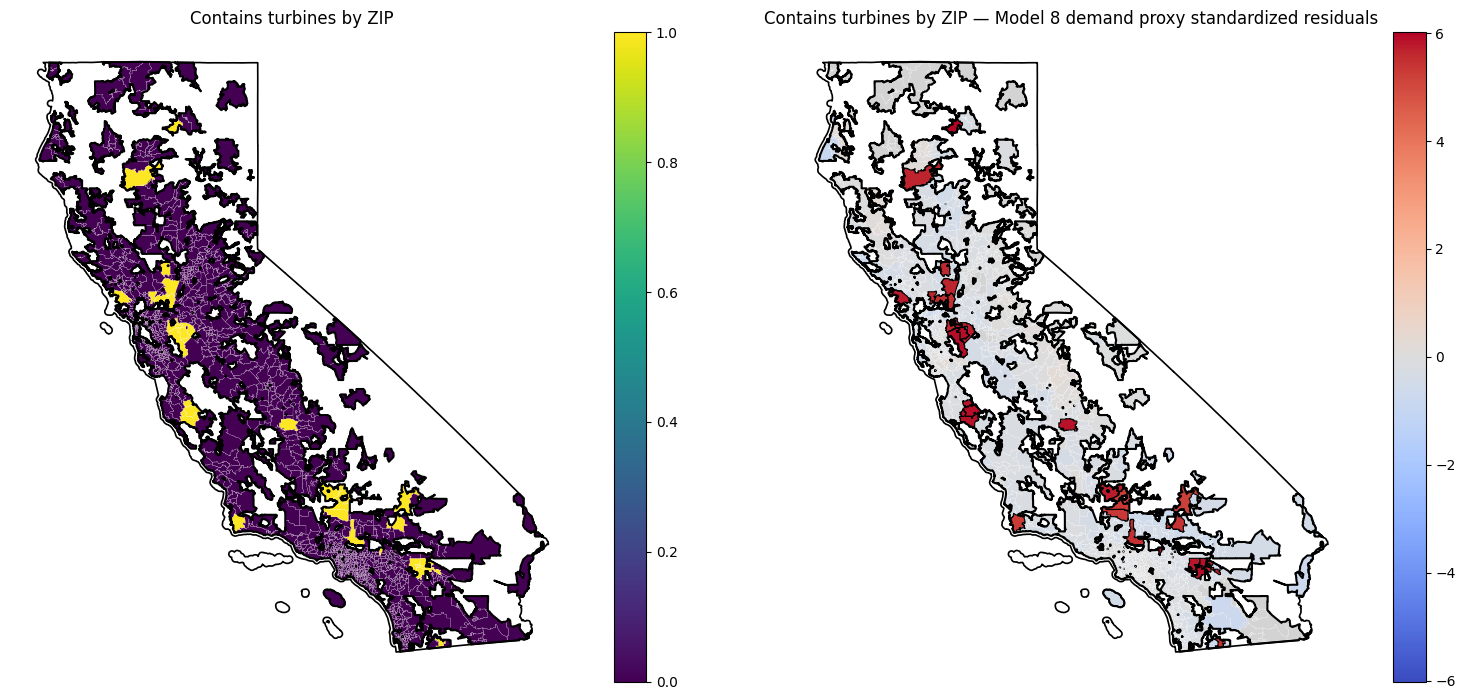

{'Model 1 baseline (climate controls)': '../outputs/figures/y_turbines_maps/any_turbines_model_1_baseline_climate_controls_spatial_figure.png',
 'Model 2a add bachelors': '../outputs/figures/y_turbines_maps/any_turbines_model_2a_add_bachelors_spatial_figure.png',
 'Model 2b add housing value': '../outputs/figures/y_turbines_maps/any_turbines_model_2b_add_housing_value_spatial_figure.png',
 'Model 3a HDD + CDD': '../outputs/figures/y_turbines_maps/any_turbines_model_3a_hdd_cdd_spatial_figure.png',
 'Model 3b temp only': '../outputs/figures/y_turbines_maps/any_turbines_model_3b_temp_only_spatial_figure.png',
 'Model 3c GHI only': '../outputs/figures/y_turbines_maps/any_turbines_model_3c_ghi_only_spatial_figure.png',
 'Model 4 interactions': '../outputs/figures/y_turbines_maps/any_turbines_model_4_interactions_spatial_figure.png',
 'Model 4R interactions reduced': '../outputs/figures/y_turbines_maps/any_turbines_model_4r_interactions_reduced_spatial_figure.png',
 'Model 5 utility FE': '..

In [1989]:
import os
import re
models = {
    "Model 1 baseline (climate controls)": res1,
    "Model 2a add bachelors": res2a,
    "Model 2b add housing value": res2b,
    "Model 3a HDD + CDD": res3a,
    "Model 3b temp only": res3b,
    "Model 3c GHI only": res3c,
    "Model 4 interactions": res4,
    "Model 4R interactions reduced": res4R,
    "Model 5 utility FE": res5,
    "Model 5C clustered SEs by county": res5C,
    "Model 6a lat lon": res6a,
    "Model 6b county FE": res6b,
    "Model 6 FE clustered": res6_fe_cluster,
    "Model 7 infrastructure controls": res7,
    "Model 7pc per-capita infrastructure controls": res7pc,
    "Model 8 demand proxy": res8,
}

saved_maps = export_spatial_maps_for_models(
    df=df,
    zip_gdf=zip_gdf,
    outcome_col=y,
    outcome_title=f"{term_labels[y]} by ZIP",
    model_results=models,
    id_col="zip_code",
    output_dir=f"../outputs/figures/{y[2:]}_maps/",
    hotspot_threshold=2.0,
    ca_outline_gdf=ca_outline,
)
# add outline to ca maps
saved_maps